In [226]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import pandas as pd

Initialize Ticker Value

In [227]:
TICKER = "AAPL"
cash = 5000

Function to update portfolio.

In [228]:
def update_portfolio(amount, shares):
    path = Path('portfolio.json')
    content = json.dumps({"cash": amount, "shares": shares})
    path.write_text(content)

Load nescessary data.

In [229]:
def download_data(TICKER):
    data = yf.download(TICKER, start="2020-01-01")
    data = data["Close"][TICKER].to_frame(name="Close")
    data_2020 = data.loc["2020-01-01": "2020-12-31"]
    data_2025_26 = data.loc["2025-01-01":]
    # change to json.load
    #cash = 10000
    return data_2020, data, data_2025_26
data_2020, data, data_2025_26 = download_data(TICKER)

[*********************100%***********************]  1 of 1 completed


Return the moving average for the past n days.

In [230]:
def sma(data, n, name):
    """Simple Moving Average"""
    data[name] = data["Close"].rolling(n).mean()
    return data

def ema(data, n, name):
    """Exponential Moving Average"""
    data[name] = data["Close"].ewm(span=n, adjust=False).mean()
    return data

In [231]:
def ma_strategy(data, starting_cash, ma_type="s"):
    if ma_type == "s":
        sma(data, 20, "Short_ma")
        sma(data, 50, "Long_ma")
    elif ma_type == "e":
        ema(data, 20, "Short_ma")
        ema(data, 50, "Long_ma")
    # Initialize variables to eventually return
    shares = 0
    portfolio_values = [starting_cash]
    cash = starting_cash

    for i in range(1, len(data)):
        # Assign the closing price of day i to a variable
        price = float(data["Close"].iloc[i])

        # Find the Short/Long Moving average of day i in the dataset for today and yesterday
        todays_short = float(data["Short_ma"].iloc[i])
        yesterdays_short = float(data["Short_ma"].iloc[i - 1])
        todays_long = float(data["Long_ma"].iloc[i])
        yesterdays_long = float(data["Long_ma"].iloc[i - 1])

        # Assign 25% of the cash in your portfolio to the strategy to use when there is a trend reversal.
        purchase_power = cash / 2
        
        # Check to see if the short or longs are null, if not follow through with the strategy
        if (
        not pd.isna(todays_short)
        and not pd.isna(todays_long)
        and not pd.isna(yesterdays_short)
        and not pd.isna(yesterdays_long)
            ):

            # Basically if yesterdays short MA is greater than or equal to yesterdays long MA and todays short MA is less than todays long this indicates a downtrend
            downtrend = yesterdays_short >= yesterdays_long and todays_short < todays_long
            # If yesterdays short MA is less than or equal yesterdays long MA and todays short MA is greater than todays long this indicates a uptrend
            uptrend = todays_short > todays_long and yesterdays_long >= yesterdays_short

            # If there is a uptrend and you have cash available go to the next step
            if uptrend and cash > 0:
                # Check if your allocated purchase money is more than the price if so go to the next step
                if purchase_power >= price:
                    # Create a variable to represent the number of shares bought by dividing your allocated money by the price of the stock
                    shares_bought = purchase_power / price
                    # Add the amount of bought shares to your portfolio
                    shares += shares_bought
                    # Remove the cash from your portfolio by multiplying the price of the share by the amount of shares you bought on day i
                    cash -= shares_bought * price
                    print("BUY", price)

            # If there is a downtrend and you have more than 0 stocks move to the next step
            elif shares > 0 and downtrend:
                # Sell all of your shares and add the price of your shares to your cash in your portfolio
                cash += shares * price
                shares = 0
                print("SELL", price)

        current_value = cash + shares * price
        portfolio_values.append(current_value)

    data["Portfolio_Value"] = portfolio_values
    print(portfolio_values[0], portfolio_values[-1])
    return data, cash, shares

In [232]:
def plot_ma_graph(TICKER, data):
    plt.figure(figsize=(12, 6))
    plt.title("Moving Average Graph")
    plt.plot(data.index, data["Close"], label=TICKER)
    #plt.plot(data.index, data["Portfolio_Value"], label="Portfolio")
    plt.plot(data.index, data["Short_ma"], label="Short_ma")
    plt.plot(data.index, data["Long_ma"], label="Long Moving Avg")

    plt.legend()
    plt.show()

In [233]:
def normalized_portfolio_performance(TICKER, data):
    portfolio_norm = data["Portfolio_Value"] / data["Portfolio_Value"].iloc[0]
    stock_norm = data["Close"] / data["Close"].iloc[0]
    plt.figure(figsize=(12, 6))
    plt.title("Normalized Portfolio vs Stock Price")
    plt.plot(data.index, stock_norm, label = "stock price")
    plt.plot(data.index, portfolio_norm, label = "portfolio value")
    plt.legend()
    plt.show()

In [234]:
def plot_strategy_vs_stock_returns(TICKER, data):
    portfolio_return = (data["Portfolio_Value"] / data["Portfolio_Value"].iloc[0] - 1) * 100
    stock_return = (data["Close"] / data["Close"].iloc[0] - 1) * 100

    plt.figure(figsize=(12, 6))
    plt.title("Strategy Return vs Buy-and-Hold Return")
    plt.plot(data.index, stock_return, label=f"{TICKER} Buy-and-Hold Return")
    plt.plot(data.index, portfolio_return, label="Strategy Return")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.legend()
    plt.show()


In [235]:
def performance_metrics(data):
    amount_earned = round(data["Portfolio_Value"].iloc[-1] - data["Portfolio_Value"].iloc[0], 2)
    portfolio_return = round(((data["Portfolio_Value"].iloc[-1]  - data["Portfolio_Value"].iloc[0]) / data["Portfolio_Value"].iloc[0]) * 100, 2)
    stock_return = round(((data["Close"].iloc[-1] - data["Close"].iloc[0]) /  data["Close"].iloc[0]) * 100, 2)
    return_benchmark = round(portfolio_return - stock_return, 2)

    print("-" * 25)
    print("PERFORMANCE METRICS")
    print("-" * 25)
    print(f"Amount earned: {amount_earned}\nPortfolio return: {portfolio_return}%\nStock return: {stock_return}%\nReturn benchmark: {return_benchmark}%")

BUY 74.63750457763672
SELL 66.08951568603516
BUY 69.8468017578125
SELL 124.46688079833984
BUY 130.93421936035156
SELL 121.8099136352539
BUY 128.58091735839844
SELL 135.95533752441406
BUY 146.0586395263672
SELL 161.78204345703125
BUY 172.05015563964844
SELL 159.5873260498047
BUY 151.1968231201172
SELL 151.79005432128906
BUY 143.13465881347656
SELL 174.52464294433594
BUY 187.5025634765625
SELL 175.503173828125
BUY 184.4834747314453
SELL 182.48919677734375
BUY 182.90541076660156
SELL 222.61392211914062
BUY 243.80738830566406
SELL 219.88165283203125
BUY 210.4994354248047
SELL 260.8059387207031
BUY 277.8599853515625
SELL 257.4599914550781
BUY 273.04998779296875
5000 8209.521764880923
-------------------------
PERFORMANCE METRICS
-------------------------
Amount earned: 3209.52
Portfolio return: 64.19%
Stock return: 292.51%
Return benchmark: -228.32%


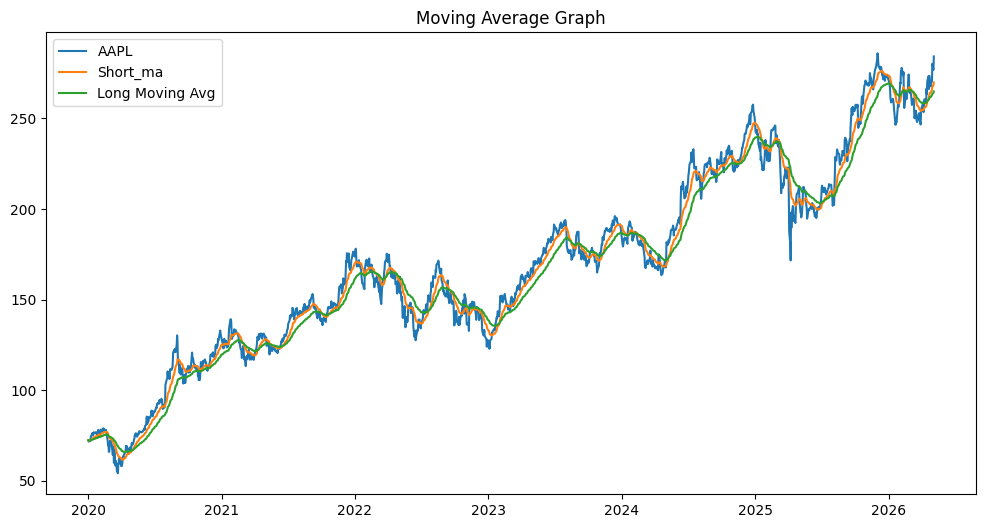

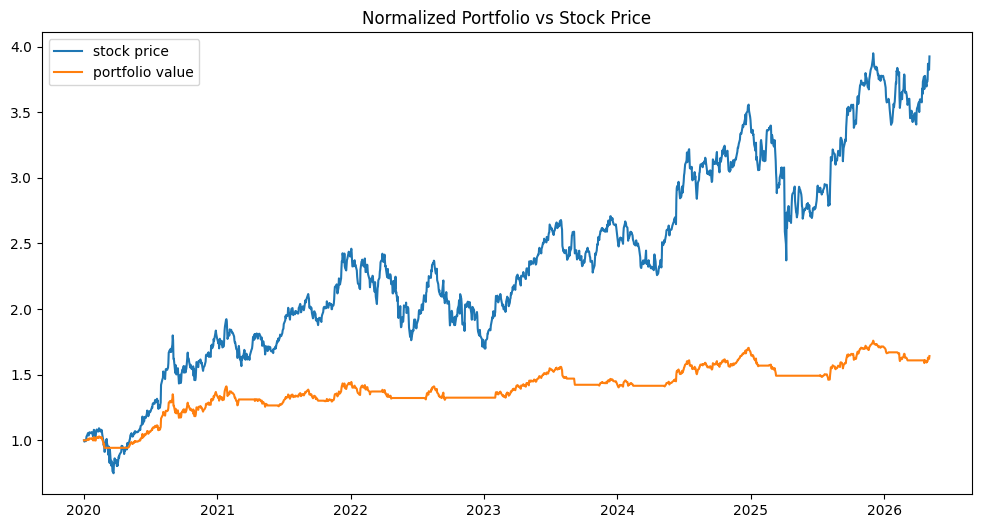

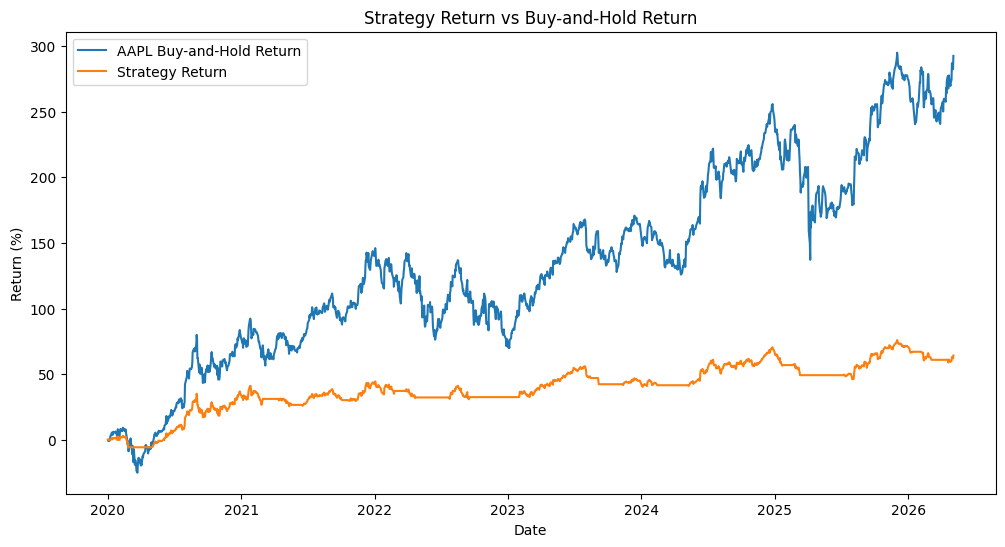

In [236]:
data, cash, shares = ma_strategy(data, cash, "e")
performance_metrics(data)
plot_ma_graph(TICKER, data)
normalized_portfolio_performance(TICKER, data)
plot_strategy_vs_stock_returns(TICKER, data)
